In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

print("Library siap.")

Library siap.


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
PATH = "/content/drive/MyDrive/Machine Learning/mahasiswa_lulus.csv"

df = pd.read_csv(PATH)
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (500, 8)


,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Lulus_Tepat_Waktu
0,2.60,65.0,9.0,Ya,Menengah,P,Tidak,Ya
1,2.76,75.0,16.2,Ya,Tinggi,L,Ya,Ya
2,2.61,66.0,12.6,Tidak,Tinggi,P,Tidak,Ya
3,2.65,75.0,10.9,Ya,Menengah,P,Tidak,Ya
4,2.77,74.0,11.6,Ya,Menengah,L,Tidak,Ya


In [7]:
df.info()

print("\n=== STATISTIK NUMERIK ===")
display(df.describe().round(2))

print("=== MISSING VALUE ===")
miss = pd.DataFrame({"jumlah": df.isna().sum(), "persen": (df.isna().mean()*100).round(2)})
display(miss[miss["jumlah"] > 0])
print("Total sel kosong:", int(df.isna().sum().sum()))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IPK                485 non-null    float64
 1   Kehadiran          482 non-null    float64
 2   Jam_Belajar        480 non-null    float64
 3   Organisasi         490 non-null    object 
 4   Penghasilan_Ortu   486 non-null    object 
 5   Jenis_Kelamin      500 non-null    object 
 6   Status_Beasiswa    500 non-null    object 
 7   Lulus_Tepat_Waktu  500 non-null    object 
dtypes: float64(3), object(5)
memory usage: 31.4+ KB

=== STATISTIK NUMERIK ===


,IPK,Kehadiran,Jam_Belajar
count,485.00,482.00,480.00
mean,2.92,71.02,11.61
std,0.45,10.90,4.01
min,1.80,43.00,1.00
25%,2.61,63.25,8.90
50%,2.91,72.00,11.90
75%,3.21,78.00,14.30
max,4.00,100.00,23.20


=== MISSING VALUE ===


,jumlah,persen
IPK,15,3.0
Kehadiran,18,3.6
Jam_Belajar,20,4.0
Organisasi,10,2.0
Penghasilan_Ortu,14,2.8


Total sel kosong: 77


Lulus_Tepat_Waktu
Ya       352
Tidak    148
Name: count, dtype: int64

Proporsi (%):
Lulus_Tepat_Waktu
Ya       70.4
Tidak    29.6
Name: proportion, dtype: float64

Baseline (selalu kelas mayoritas): 0.704


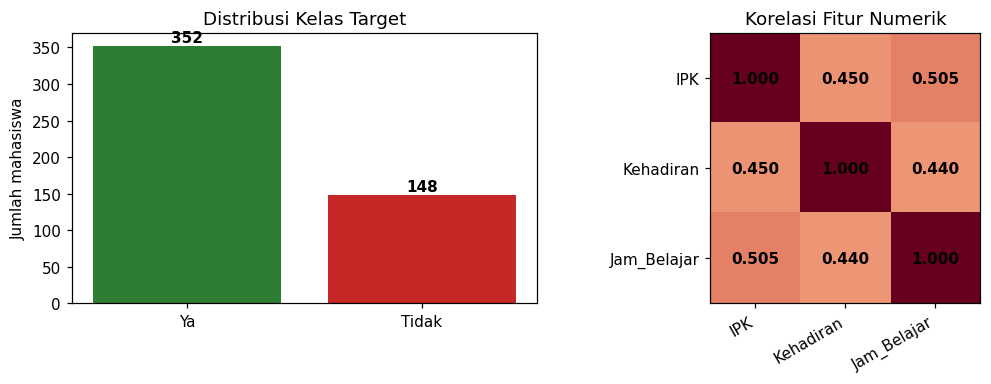

,IPK,Kehadiran,Jam_Belajar
IPK,1.000,0.45,0.505
Kehadiran,0.450,1.00,0.440
Jam_Belajar,0.505,0.44,1.000


In [8]:
TARGET = "Lulus_Tepat_Waktu"
num_cols = ["IPK", "Kehadiran", "Jam_Belajar"]
cat_cols = ["Organisasi", "Penghasilan_Ortu", "Jenis_Kelamin", "Status_Beasiswa"]

dist = df[TARGET].value_counts()
print(dist)
print("\nProporsi (%):"); print((df[TARGET].value_counts(normalize=True)*100).round(2))
print("\nBaseline (selalu kelas mayoritas): %.3f" % (dist.max()/dist.sum()))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].bar(dist.index.astype(str), dist.values, color=["#2E7D32", "#C62828"])
for i, v in enumerate(dist.values):
    axes[0].text(i, v+5, str(v), ha="center", fontweight="bold")
axes[0].set_title("Distribusi Kelas Target"); axes[0].set_ylabel("Jumlah mahasiswa")

corr = df[num_cols].corr()
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(num_cols, rotation=30, ha="right")
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(num_cols)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, format(corr.iloc[i,j], ".3f"), ha="center", va="center", fontweight="bold")
axes[1].set_title("Korelasi Fitur Numerik")
plt.tight_layout(); plt.savefig("gbr_1_eda.png", bbox_inches="tight"); plt.show()

display(corr.round(3))

In [9]:
X_raw = df[num_cols + cat_cols].copy()
y = (df[TARGET] == "Ya").astype(int)          # 1 = lulus tepat waktu

# (c) split 80:20 — DILAKUKAN SEBELUM imputasi, agar tidak data leakage
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train_raw.shape[0], "| Test:", X_test_raw.shape[0])
print("Proporsi kelas 1 -> train %.3f | test %.3f" % (y_train.mean(), y_test.mean()))

# (a) missing value: median & modus DARI DATA LATIH SAJA
impute_num = {c: X_train_raw[c].median() for c in num_cols}
impute_cat = {c: X_train_raw[c].mode()[0] for c in cat_cols}
print("\nNilai pengisi:", impute_num, impute_cat)

X_train_imp = X_train_raw.fillna({**impute_num, **impute_cat})
X_test_imp  = X_test_raw.fillna({**impute_num, **impute_cat})
print("Sisa NaN -> train:", int(X_train_imp.isna().sum().sum()), "| test:", int(X_test_imp.isna().sum().sum()))

Train: 400 | Test: 100
Proporsi kelas 1 -> train 0.705 | test 0.700

Nilai pengisi: {'IPK': 2.92, 'Kehadiran': 72.0, 'Jam_Belajar': 11.8} {'Organisasi': 'Ya', 'Penghasilan_Ortu': 'Menengah', 'Jenis_Kelamin': 'P', 'Status_Beasiswa': 'Tidak'}
Sisa NaN -> train: 0 | test: 0


In [10]:
# (b) encoding: biner + ordinal
MAPS = {
    "Organisasi":       {"Tidak": 0, "Ya": 1},
    "Status_Beasiswa":  {"Tidak": 0, "Ya": 1},
    "Jenis_Kelamin":    {"L": 0, "P": 1},
    "Penghasilan_Ortu": {"Rendah": 0, "Menengah": 1, "Tinggi": 2},   # ordinal, berjenjang
}

def encode(dfx):
    out = dfx.copy()
    for col, m in MAPS.items():
        out[col] = out[col].map(m).astype(int)
    return out

X_train, X_test = encode(X_train_imp), encode(X_test_imp)
FEATURES = list(X_train.columns)

print("Fitur:", FEATURES)
display(X_train.head())
assert X_train.isna().sum().sum() == 0
print("Preprocessing selesai.")

Fitur: ['IPK', 'Kehadiran', 'Jam_Belajar', 'Organisasi', 'Penghasilan_Ortu', 'Jenis_Kelamin', 'Status_Beasiswa']


,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa
209,3.00,58.0,9.0,1,1,1,0
467,3.03,88.0,11.4,1,0,1,0
156,3.57,57.0,11.6,1,2,0,0
238,2.92,48.0,9.3,0,1,0,0
451,2.13,62.0,14.4,0,0,1,0


Preprocessing selesai.


In [11]:
dt3     = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
dt_full = DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)
gnb     = GaussianNB()

models = {
    "Decision Tree (max_depth=3)":    dt3,
    "Decision Tree (max_depth=None)": dt_full,
    "Gaussian Naive Bayes":           gnb,
}
for nama, m in models.items():
    m.fit(X_train, y_train); print("[OK]", nama)

print("\nUkuran pohon:")
print("  depth=3    -> kedalaman %d, daun %d" % (dt3.get_depth(), dt3.get_n_leaves()))
print("  depth=None -> kedalaman %d, daun %d" % (dt_full.get_depth(), dt_full.get_n_leaves()))

# bukti overfitting
gap = pd.DataFrame([{
    "Model": n,
    "Train Acc": round(accuracy_score(y_train, m.predict(X_train)), 4),
    "Test Acc":  round(accuracy_score(y_test,  m.predict(X_test)), 4),
} for n, m in models.items()])
gap["Gap"] = (gap["Train Acc"] - gap["Test Acc"]).round(4)
display(gap)

[OK] Decision Tree (max_depth=3)
[OK] Decision Tree (max_depth=None)
[OK] Gaussian Naive Bayes

Ukuran pohon:
  depth=3    -> kedalaman 3, daun 8
  depth=None -> kedalaman 18, daun 90


,Model,Train Acc,Test Acc,Gap
0,Decision Tree (max_depth=3),0.7875,0.71,0.0775
1,Decision Tree (max_depth=None),1.0000,0.68,0.3200
2,Gaussian Naive Bayes,0.7500,0.75,0.0000


In [12]:
hasil, pred_store = [], {}
for nama, m in models.items():
    yp = m.predict(X_test); pred_store[nama] = yp
    hasil.append({
        "Model": nama,
        "Akurasi":   accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, pos_label=1, zero_division=0),
        "Recall":    recall_score(y_test, yp, pos_label=1, zero_division=0),
        "F1-Score":  f1_score(y_test, yp, pos_label=1, zero_division=0),
        "F1-Macro":  f1_score(y_test, yp, average="macro", zero_division=0),
    })

metrik_df = pd.DataFrame(hasil).set_index("Model").round(4)
display(metrik_df)
metrik_df.to_csv("tabel_metrik.csv")

for nama, yp in pred_store.items():
    print("="*66); print(nama); print("="*66)
    print(classification_report(y_test, yp,
          target_names=["Tidak Lulus Tepat Waktu", "Lulus Tepat Waktu"], zero_division=0))

,Akurasi,Precision,Recall,F1-Score,F1-Macro
Model,,,,,
Decision Tree (max_depth=3),0.71,0.7470,0.8857,0.8105,0.5967
Decision Tree (max_depth=None),0.68,0.7794,0.7571,0.7681,0.6260
Gaussian Naive Bayes,0.75,0.8358,0.8000,0.8175,0.7103


Decision Tree (max_depth=3)
                         precision    recall  f1-score   support

Tidak Lulus Tepat Waktu       0.53      0.30      0.38        30
      Lulus Tepat Waktu       0.75      0.89      0.81        70

               accuracy                           0.71       100
              macro avg       0.64      0.59      0.60       100
           weighted avg       0.68      0.71      0.68       100

Decision Tree (max_depth=None)
                         precision    recall  f1-score   support

Tidak Lulus Tepat Waktu       0.47      0.50      0.48        30
      Lulus Tepat Waktu       0.78      0.76      0.77        70

               accuracy                           0.68       100
              macro avg       0.62      0.63      0.63       100
           weighted avg       0.69      0.68      0.68       100

Gaussian Naive Bayes
                         precision    recall  f1-score   support

Tidak Lulus Tepat Waktu       0.58      0.63      0.60        30
   

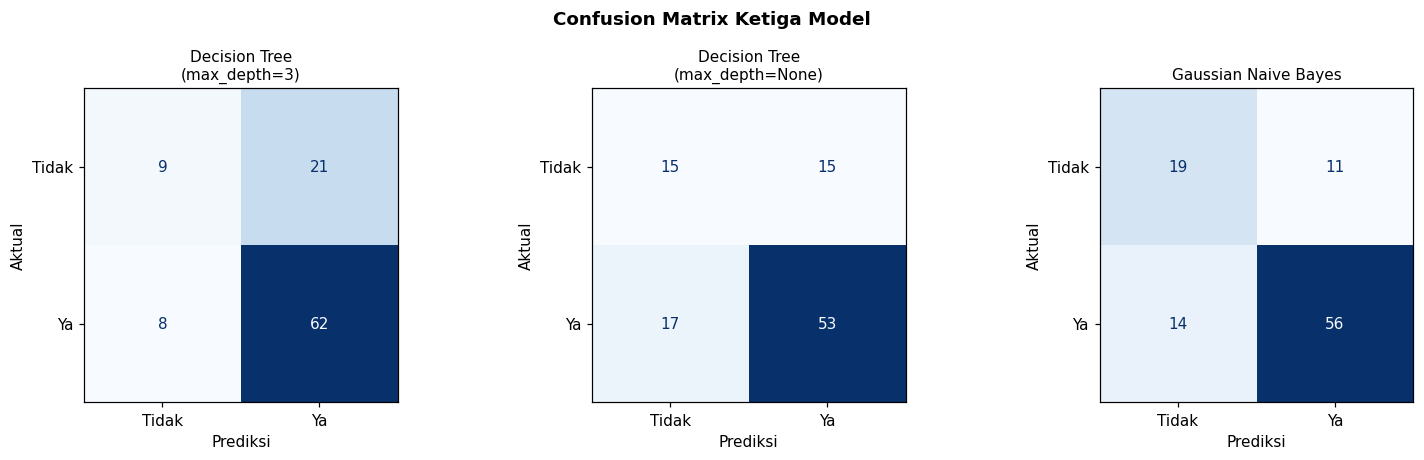


Decision Tree (max_depth=3)
  TN=9  FP=21 (diprediksi lulus padahal tidak)
  FN=8 (diprediksi tidak padahal lulus)  TP=62

Decision Tree (max_depth=None)
  TN=15  FP=15 (diprediksi lulus padahal tidak)
  FN=17 (diprediksi tidak padahal lulus)  TP=53

Gaussian Naive Bayes
  TN=19  FP=11 (diprediksi lulus padahal tidak)
  FN=14 (diprediksi tidak padahal lulus)  TP=56


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (nama, yp) in zip(axes, pred_store.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, yp),
        display_labels=["Tidak", "Ya"]).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(nama.replace(" (", "\n("), fontsize=10)
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
plt.suptitle("Confusion Matrix Ketiga Model", fontweight="bold")
plt.tight_layout(); plt.savefig("gbr_2_confusion_matrix.png", bbox_inches="tight"); plt.show()

for nama, yp in pred_store.items():
    tn, fp, fn, tp = confusion_matrix(y_test, yp).ravel()
    print(f"\n{nama}\n  TN={tn}  FP={fp} (diprediksi lulus padahal tidak)"
          f"\n  FN={fn} (diprediksi tidak padahal lulus)  TP={tp}")

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all = encode(X_raw.fillna({**impute_num, **impute_cat}))
for nama, m in models.items():
    s = cross_val_score(m, X_all, y, cv=cv, scoring="f1_macro")
    print("%-32s %.4f +/- %.4f" % (nama, s.mean(), s.std()))

Decision Tree (max_depth=3)      0.6058 +/- 0.0252
Decision Tree (max_depth=None)   0.6344 +/- 0.0346
Gaussian Naive Bayes             0.7015 +/- 0.0129


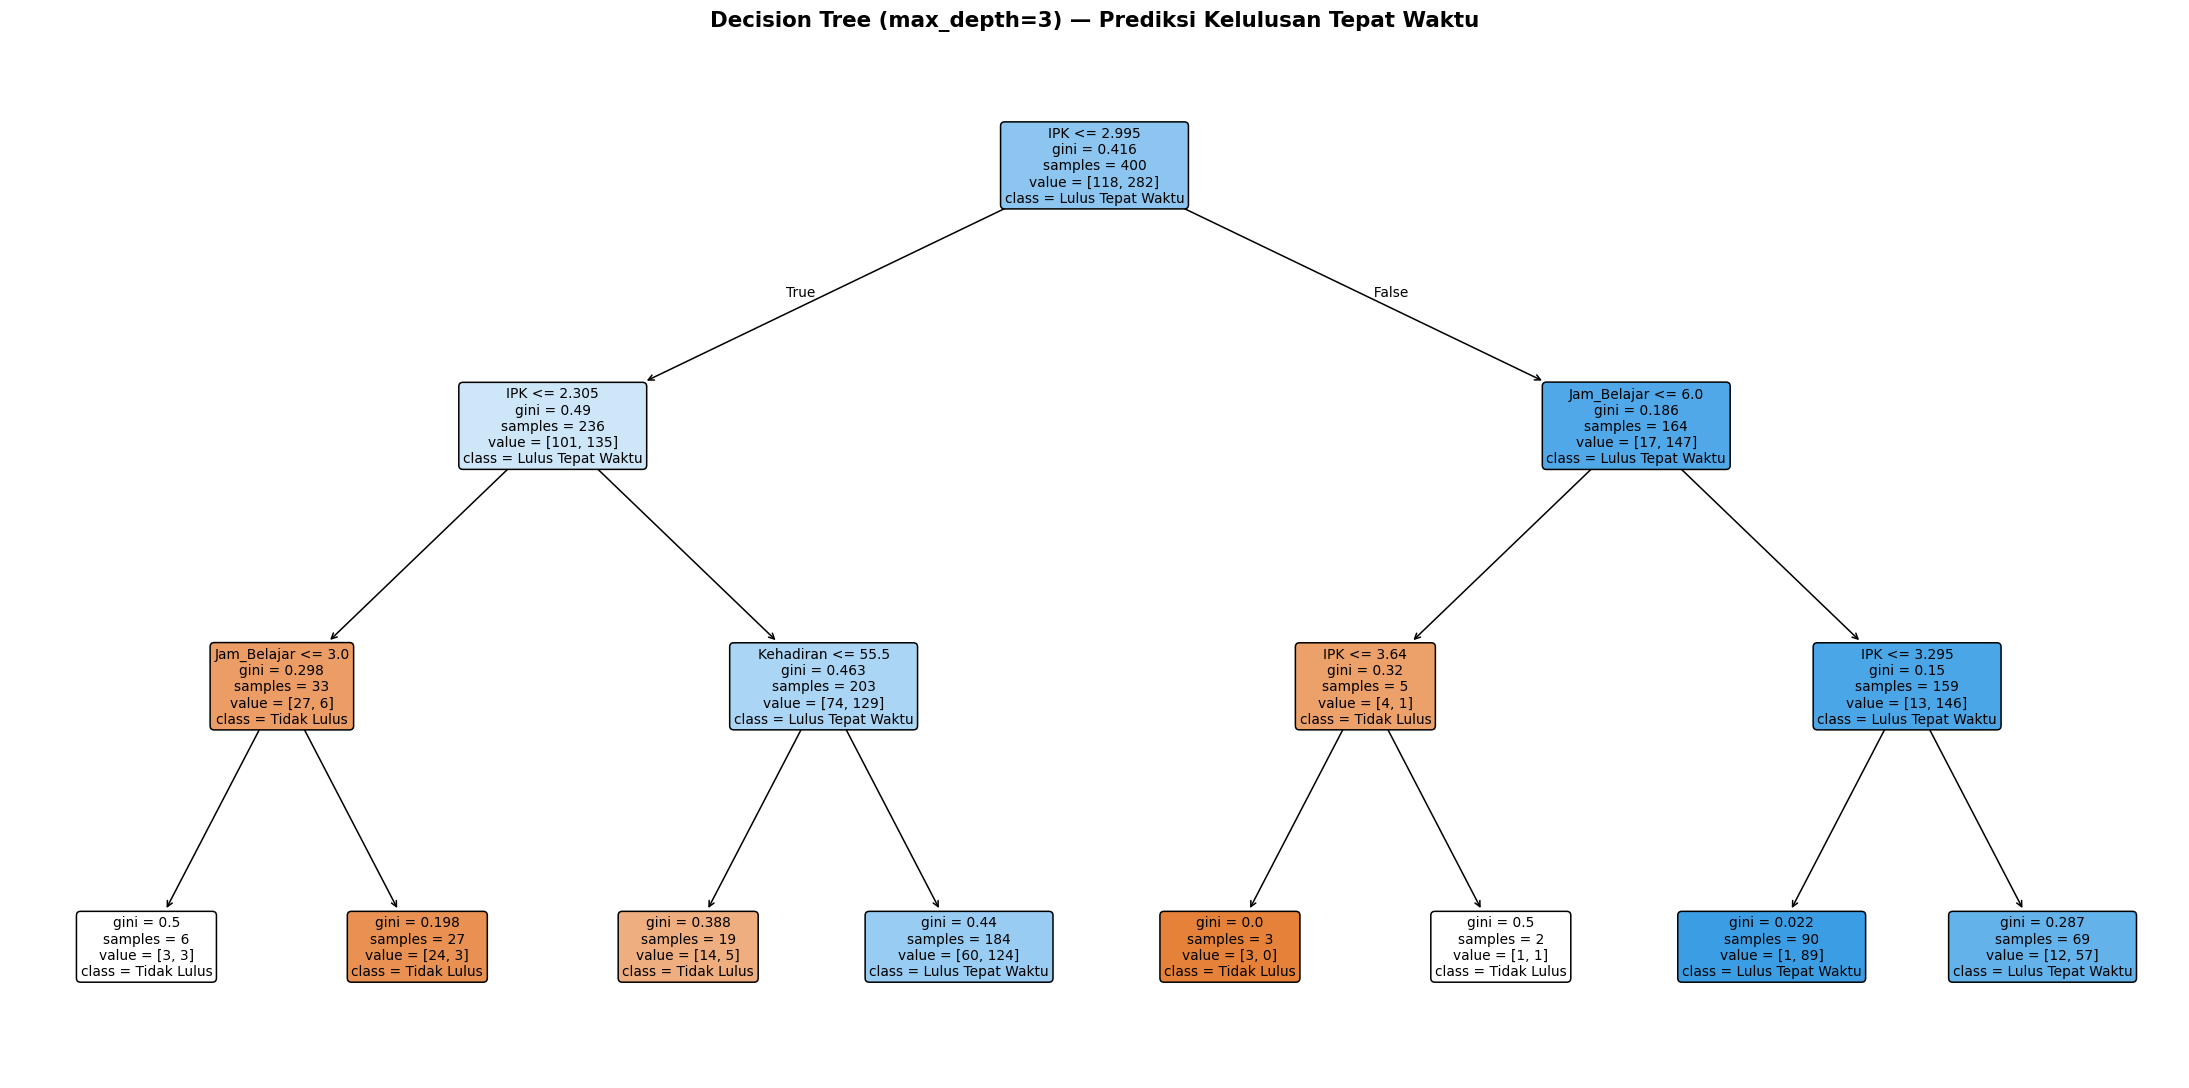

|--- IPK <= 3.00
|   |--- IPK <= 2.30
|   |   |--- Jam_Belajar <= 3.00
|   |   |   |--- class: 0
|   |   |--- Jam_Belajar >  3.00
|   |   |   |--- class: 0
|   |--- IPK >  2.30
|   |   |--- Kehadiran <= 55.50
|   |   |   |--- class: 0
|   |   |--- Kehadiran >  55.50
|   |   |   |--- class: 1
|--- IPK >  3.00
|   |--- Jam_Belajar <= 6.00
|   |   |--- IPK <= 3.64
|   |   |   |--- class: 0
|   |   |--- IPK >  3.64
|   |   |   |--- class: 0
|   |--- Jam_Belajar >  6.00
|   |   |--- IPK <= 3.29
|   |   |   |--- class: 1
|   |   |--- IPK >  3.29
|   |   |   |--- class: 1



,0
IPK,0.7384
Jam_Belajar,0.1380
Kehadiran,0.1236
Organisasi,0.0000
Penghasilan_Ortu,0.0000
Jenis_Kelamin,0.0000
Status_Beasiswa,0.0000


In [15]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(dt3, feature_names=FEATURES, class_names=["Tidak Lulus", "Lulus Tepat Waktu"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree (max_depth=3) — Prediksi Kelulusan Tepat Waktu",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("gbr_3_pohon.png", dpi=150, bbox_inches="tight"); plt.show()

print(export_text(dt3, feature_names=FEATURES, decimals=2))
display(pd.Series(dt3.feature_importances_, index=FEATURES).sort_values(ascending=False).round(4))

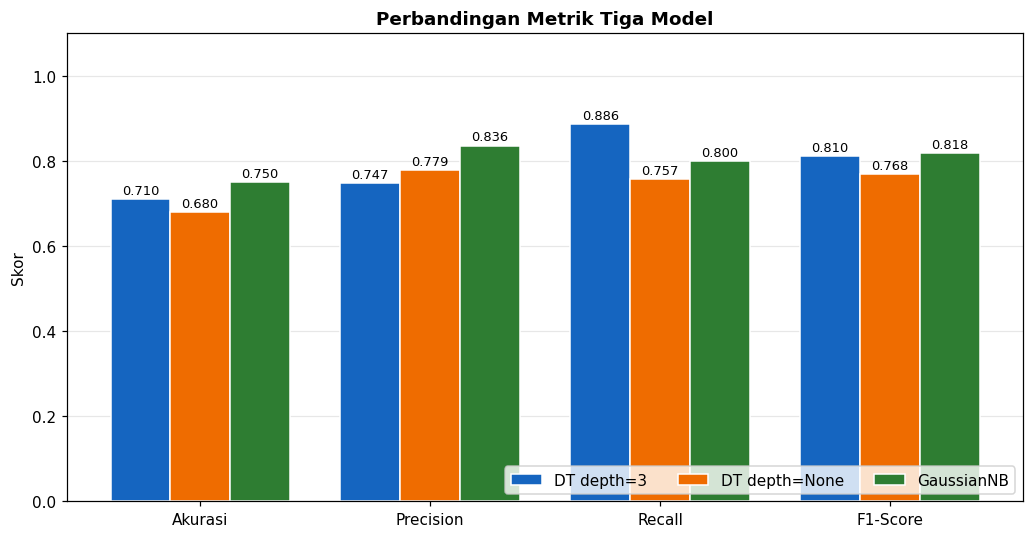

In [16]:
metrik_plot = ["Akurasi", "Precision", "Recall", "F1-Score"]
pendek = ["DT depth=3", "DT depth=None", "GaussianNB"]
warna  = ["#1565C0", "#EF6C00", "#2E7D32"]
x, w = np.arange(4), 0.26

fig, ax = plt.subplots(figsize=(9.5, 5))
for i, (lbl, nama) in enumerate(zip(pendek, metrik_df.index)):
    nilai = metrik_df.loc[nama, metrik_plot].values.astype(float)
    pos = x + (i-1)*w
    ax.bar(pos, nilai, w, label=lbl, color=warna[i], edgecolor="white")
    for xp, v in zip(pos, nilai):
        ax.text(xp, v+0.012, format(v, ".3f"), ha="center", fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(metrik_plot); ax.set_ylim(0, 1.10)
ax.set_ylabel("Skor"); ax.set_title("Perbandingan Metrik Tiga Model", fontweight="bold")
ax.legend(loc="lower right", ncol=3); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.savefig("gbr_4_metrik.png", dpi=150, bbox_inches="tight"); plt.show()

In [17]:
MODEL_PILIH = "Decision Tree (max_depth=3)"
m_pilih = models[MODEL_PILIH]
proba = m_pilih.predict_proba(X_test)[:, 1]
lab = {0: "Tidak", 1: "Ya"}

banding = X_test_raw.copy()                       # nilai ASLI, termasuk NaN
banding["Aktual"]     = y_test.map(lab)
banding["Prediksi"]   = pd.Series(pred_store[MODEL_PILIH], index=X_test_raw.index).map(lab)
banding["Prob_Lulus"] = proba.round(3)

salah = banding[banding["Aktual"] != banding["Prediksi"]].copy()
print("Salah prediksi: %d dari %d (%.1f%%)" % (len(salah), len(banding), len(salah)/len(banding)*100))

salah["yakin"] = (salah["Prob_Lulus"] - 0.5).abs()
top5 = salah.sort_values("yakin", ascending=False).head(5).drop(columns="yakin")
display(top5)
top5.to_csv("tabel_5_error.csv")

print("\n=== RATA-RATA PER KELAS (pembanding) ===")
display(df.groupby(TARGET)[num_cols].mean().round(2))

Salah prediksi: 29 dari 100 (29.0%)


,IPK,Kehadiran,Jam_Belajar,Organisasi,Penghasilan_Ortu,Jenis_Kelamin,Status_Beasiswa,Aktual,Prediksi,Prob_Lulus
459,3.15,74.0,15.3,Tidak,Menengah,P,Tidak,Tidak,Ya,0.989
256,3.24,68.0,13.6,Ya,Rendah,P,Tidak,Tidak,Ya,0.989
61,2.21,69.0,10.5,Ya,Rendah,L,Tidak,Ya,Tidak,0.111
466,2.07,64.0,6.0,Ya,Tinggi,P,Tidak,Ya,Tidak,0.111
492,2.25,70.0,13.4,Ya,Menengah,P,Tidak,Ya,Tidak,0.111



=== RATA-RATA PER KELAS (pembanding) ===


,IPK,Kehadiran,Jam_Belajar
Lulus_Tepat_Waktu,,,
Tidak,2.66,65.19,9.85
Ya,3.02,73.46,12.36


In [20]:
mhs = pd.DataFrame([{"IPK": 3.75, "Kehadiran": 55.0, "Jam_Belajar": 8.0,
                     "Organisasi": 1, "Penghasilan_Ortu": 1,
                     "Jenis_Kelamin": 0, "Status_Beasiswa": 1}])[FEATURES]

print("Profil: IPK 3.75 (tinggi), Kehadiran 55% (rendah)\n")
for nama, m in models.items():
    print("%-32s -> %-6s (P=%.3f)" % (nama, lab[m.predict(mhs)[0]], m.predict_proba(mhs)[0,1]))

print("\n=== SENSITIVITAS KEHADIRAN (IPK tetap 3.75) ===")
for kh in [45, 55, 65, 75, 85]:
    u = mhs.copy(); u["Kehadiran"] = float(kh)
    print("Kehadiran %2d%% -> DT: %.3f | NB: %.3f" % (kh, dt3.predict_proba(u)[0,1], gnb.predict_proba(u)[0,1]))

Profil: IPK 3.75 (tinggi), Kehadiran 55% (rendah)

Decision Tree (max_depth=3)      -> Ya     (P=0.826)
Decision Tree (max_depth=None)   -> Tidak  (P=0.000)
Gaussian Naive Bayes             -> Ya     (P=0.719)

=== SENSITIVITAS KEHADIRAN (IPK tetap 3.75) ===
Kehadiran 45% -> DT: 0.826 | NB: 0.437
Kehadiran 55% -> DT: 0.826 | NB: 0.719
Kehadiran 65% -> DT: 0.826 | NB: 0.871
Kehadiran 75% -> DT: 0.826 | NB: 0.934
Kehadiran 85% -> DT: 0.826 | NB: 0.960


In [21]:
import shutil, glob, os
FOLDER = "/content/drive/MyDrive/Machine Learning/hasil"
os.makedirs(FOLDER, exist_ok=True)
for f in glob.glob("gbr_*.png") + glob.glob("tabel_*.csv"):
    shutil.copy(f, FOLDER); print("tersimpan:", f)

tersimpan: gbr_1_eda.png
tersimpan: gbr_3_pohon.png
tersimpan: gbr_4_metrik.png
tersimpan: gbr_2_confusion_matrix.png
tersimpan: tabel_5_error.csv
tersimpan: tabel_metrik.csv


In [23]:
# ===== SEL PEMBANDING — pendekatan Pipeline + One-Hot Encoding =====
# Tidak menimpa hasil di atas. Hanya untuk dibandingkan di laporan.

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

pipe_models = {
    "Pipeline DT depth=3":    DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Pipeline DT depth=None": DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    "Pipeline GaussianNB":    GaussianNB(),
}

hasil_pipe = []
for nama, clf in pipe_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train_raw, y_train)          # data MENTAH — imputasi & encoding otomatis
    yp = pipe.predict(X_test_raw)
    hasil_pipe.append({
        "Model":     nama,
        "Akurasi":   accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, pos_label=1, zero_division=0),
        "Recall":    recall_score(y_test, yp, pos_label=1, zero_division=0),
        "F1-Score":  f1_score(y_test, yp, pos_label=1, zero_division=0),
        "F1-Macro":  f1_score(y_test, yp, average="macro", zero_division=0),
    })

print("=== PEMBANDING: Pipeline + One-Hot Encoding ===")
display(pd.DataFrame(hasil_pipe).set_index("Model").round(4))

print("\n=== HASIL UTAMA: encoding ordinal (yang dipakai di laporan) ===")
display(metrik_df)

=== PEMBANDING: Pipeline + One-Hot Encoding ===


,Akurasi,Precision,Recall,F1-Score,F1-Macro
Model,,,,,
Pipeline DT depth=3,0.71,0.7470,0.8857,0.8105,0.5967
Pipeline DT depth=None,0.68,0.7794,0.7571,0.7681,0.6260
Pipeline GaussianNB,0.74,0.8438,0.7714,0.8060,0.7060



=== HASIL UTAMA: encoding ordinal (yang dipakai di laporan) ===


,Akurasi,Precision,Recall,F1-Score,F1-Macro
Model,,,,,
Decision Tree (max_depth=3),0.71,0.7470,0.8857,0.8105,0.5967
Decision Tree (max_depth=None),0.68,0.7794,0.7571,0.7681,0.6260
Gaussian Naive Bayes,0.75,0.8358,0.8000,0.8175,0.7103
